# Yearn USDC Vault Analysis

Analyzes transaction patterns and token flows for the Yearn USDC vault (`0xBe53A109B494E5c9f97b9Cd39Fe969BE68BF6204`).

## Setup

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path('../src').resolve()))

import pandas as pd
from yield_aggregators.yearn_analysis import (
    plot_net_deposits_vs_withdrawals,
    calculate_deposit_redeem_statistics,
    print_deposit_redeem_statistics,
    calculate_transaction_depth_statistics,
    print_transaction_depth_statistics,
    calculate_internal_tx_depth_statistics,
    print_internal_tx_depth_statistics,
    export_deposit_redeem_transfers,
    plot_vault_exchange_rate_over_time,
    export_exchange_rate_to_csv
)

function_signatures = {
    "redeem": ["0xba087652", "0x9f40a7b3"],
    "deposit": ["0x6e553f65"],
    "strategy_investment": ["0xba54971f", "0x0aeebf55"]  
}

yearn_USDC_vault_address = "0xBe53A109B494E5c9f97b9Cd39Fe969BE68BF6204".lower()

yearn_transactions = pd.read_csv('../data/yearn_transactions.csv')
yearn_token_transfers = pd.read_csv('../data/yearn_transfers.csv')

print(f"Loaded {len(yearn_transactions):,} transactions")
print(f"Loaded {len(yearn_token_transfers):,} token transfers")


Loaded 228,443 transactions
Loaded 5,575 token transfers


/var/folders/4r/m98p1dyn123bfvxx30k78gmw0000gn/T/ipykernel_10721/2664337114.py:27: DtypeWarning: Columns (16) have mixed types. Specify dtype option on import or set low_memory=False.
  yearn_transactions = pd.read_csv('../data/yearn_transactions.csv')


## Transaction Overview

Total transactions and token transfers, broken down by function signature.

In [2]:
total_unique_txs = yearn_transactions['tx_hash'].nunique()
total_token_transfers = len(yearn_token_transfers)

print("="*70)
print("OVERALL DATA SUMMARY")
print("="*70)
print(f"Total unique transactions: {total_unique_txs:,}")
print(f"Total token transfers:      {total_token_transfers:,}")
print("="*70)

yearn_transactions['function_signature'] = yearn_transactions['input'].astype(str).str[:10]
yearn_transactions['to_normalized'] = yearn_transactions['to_address'].astype(str).str.lower()

print("\n" + "="*70)
print("BREAKDOWN BY FUNCTION (directed at vault)")
print("="*70)

for func_name, signatures in function_signatures.items():
    func_txs = yearn_transactions[
        (yearn_transactions['function_signature'].isin(signatures)) &
        (yearn_transactions['to_normalized'] == yearn_USDC_vault_address)
    ]
    unique_tx_hashes = func_txs['tx_hash'].unique()
    func_transfers = yearn_token_transfers[yearn_token_transfers['tx_hash'].isin(unique_tx_hashes)]
    
    print(f"\n{func_name.upper()}")
    print(f"  Signatures: {', '.join(signatures)}")
    print(f"  Transactions:     {len(unique_tx_hashes):>6,}")
    print(f"  Token transfers:  {len(func_transfers):>6,}")

print("\n" + "="*70)

OVERALL DATA SUMMARY
Total unique transactions: 2,459
Total token transfers:      5,575

BREAKDOWN BY FUNCTION (directed at vault)

REDEEM
  Signatures: 0xba087652, 0x9f40a7b3
  Transactions:        488
  Token transfers:   2,127

DEPOSIT
  Signatures: 0x6e553f65
  Transactions:        577
  Token transfers:   2,162

STRATEGY_INVESTMENT
  Signatures: 0xba54971f, 0x0aeebf55
  Transactions:        707
  Token transfers:   1,561



## Deposit & Redeem Statistics

Summary statistics for deposits and redeems. Includes transfer depth (token transfer chain length per transaction) and internal call depth analysis.

In [3]:
stats = calculate_deposit_redeem_statistics(
    transactions_df=yearn_transactions,
    transfers_df=yearn_token_transfers,
    function_signatures=function_signatures,
    vault_address=yearn_USDC_vault_address,
    token_symbol='USDC'
)

print_deposit_redeem_statistics(stats)


DEPOSIT & REDEEM SUMMARY STATISTICS

Total Deposits:        $       15,663,293.21 USDC
Total Redeems:         $       10,905,491.72 USDC
Net Flow:              $        4,757,801.49 USDC
----------------------------------------------------------------------

Deposit Statistics:
  Mean:                $           23,518.46 USDC
  Median:              $              534.00 USDC
  Max:                 $        1,062,034.88 USDC
  Count:                                 666 transfers

Redeem Statistics:
  Mean:                $           22,532.01 USDC
  Median:              $            2,920.33 USDC
  Max:                 $        1,023,106.88 USDC
  Count:                                 484 transfers



In [4]:
depth_stats = calculate_transaction_depth_statistics(
    transactions_df=yearn_transactions,
    transfers_df=yearn_token_transfers,
    function_signatures=function_signatures,
    vault_address=yearn_USDC_vault_address,
)

print_transaction_depth_statistics(depth_stats)


TRANSACTION DEPTH STATISTICS (token transfers per tx hash)

REDEEM
  Transactions:         483
  Mean:                4.40
  Median:              3.00
  Min:                    1
  Max:                   33

DEPOSIT
  Transactions:         571
  Mean:                3.79
  Median:              2.00
  Min:                    1
  Max:                   33

STRATEGY INVESTMENT
  Transactions:         706
  Mean:                2.21
  Median:              2.00
  Min:                    2
  Max:                    6




In [5]:
internal_depth_stats = calculate_internal_tx_depth_statistics(
    transactions_df=yearn_transactions,
    function_signatures=function_signatures,
    vault_address=yearn_USDC_vault_address,
)

print_internal_tx_depth_statistics(internal_depth_stats)


INTERNAL TRANSACTION DEPTH STATISTICS (traces per tx hash)

REDEEM
  Transactions:         886
  Mean:              178.24
  Median:             66.00
  Min:                    4
  Max:                2,406

DEPOSIT
  Transactions:         986
  Mean:              127.11
  Median:             53.00
  Min:                    4
  Max:                2,465

STRATEGY INVESTMENT
  Transactions:         738
  Mean:               78.69
  Median:             57.00
  Min:                   16
  Max:                  712




In [6]:
deposit_df, redeem_df = export_deposit_redeem_transfers(
    transactions_df=yearn_transactions,
    transfers_df=yearn_token_transfers,
    function_signatures=function_signatures,
    vault_address=yearn_USDC_vault_address,
    output_dir='../results/raw_data',
    token_symbol='USDC'
)

EXPORTED DEPOSIT AND REDEEM DATA
Deposits exported:        666 records -> ../results/raw_data/yearn_deposits.csv
Redeems exported:         484 records -> ../results/raw_data/yearn_withdrawals.csv


## Net Deposits vs. Withdrawals

Cumulative USDC deposited and withdrawn from the vault over time.


NET DEPOSITS VS WITHDRAWALS SUMMARY (USDC)

Total Deposits:                15,660,193.21 USDC
Total Withdrawals:             10,842,125.47 USDC
Net Flow:                       4,818,067.74 USDC
Final Cumulative Balance:       4,818,067.74 USDC


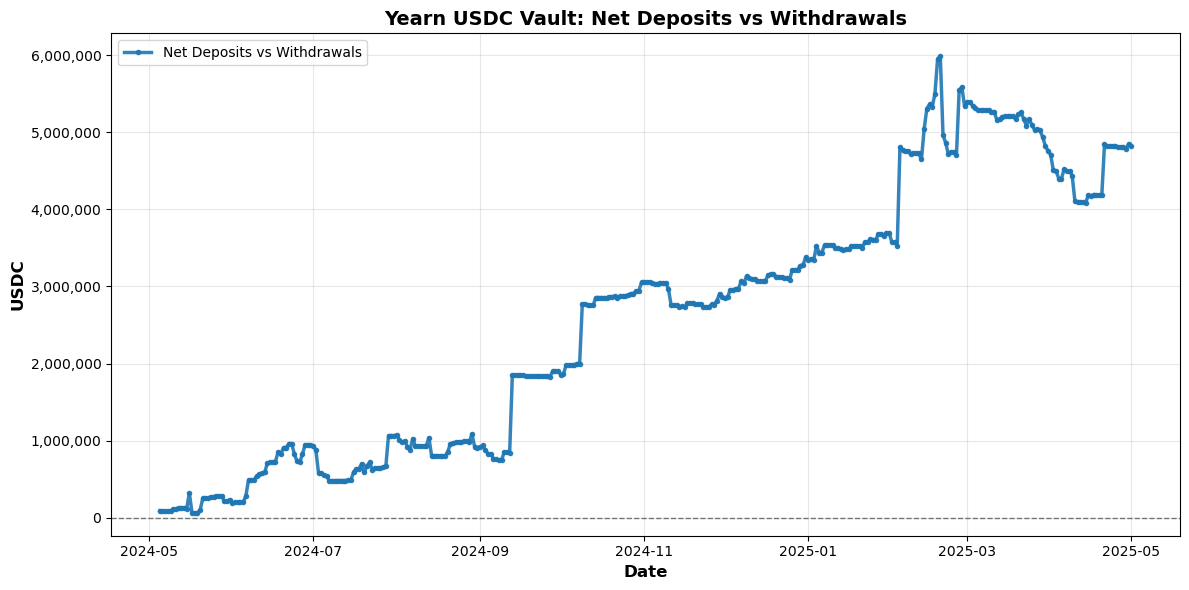

In [7]:
fig = plot_net_deposits_vs_withdrawals(
    transactions_df=yearn_transactions,
    transfers_df=yearn_token_transfers,
    function_signatures=function_signatures,
    vault_address=yearn_USDC_vault_address,
    time_column='datetime',
    freq='D',
    title='Yearn USDC Vault: Net Deposits vs Withdrawals',
    figsize=(12, 6),
    token_symbol='USDC',
    start_date='2024-05-01',
    end_date='2025-05-01'
)

In [8]:
from yield_aggregators.yearn_analysis import export_cumulative_flow_to_csv

export_cumulative_flow_to_csv(
    transactions_df=yearn_transactions,
    transfers_df=yearn_token_transfers,
    function_signatures=function_signatures,
    vault_address=yearn_USDC_vault_address,
    output_path='../results/raw_data/yearn_net_deposits.csv',
    time_column='datetime',
    freq='D',
    token_symbol='USDC'
)

Data exported to: ../results/raw_data/yearn_net_deposits.csv


## Net Flow to Strategies

Cumulative USDC deployed to external strategies vs. returned to the vault.


STRATEGY INVESTMENT FLOW SUMMARY (USDC)

Total Strategy Inflows:       158,247,111.63 USDC
Total Strategy Outflows:      171,871,534.59 USDC
Total Redeem Inflows:           8,006,732.12 USDC
Net Cumulative Flow:            5,617,690.84 USDC


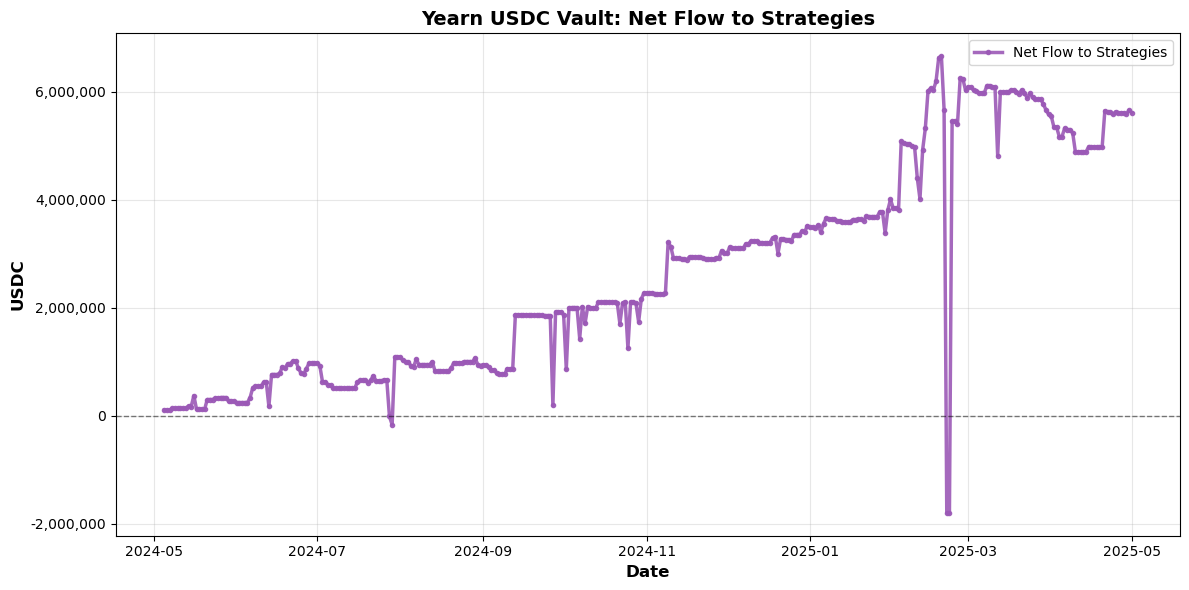

In [9]:
from yield_aggregators.yearn_analysis import plot_strategy_investment_flow

fig = plot_strategy_investment_flow(
    transactions_df=yearn_transactions,
    transfers_df=yearn_token_transfers,
    function_signatures=function_signatures,
    vault_address=yearn_USDC_vault_address,
    time_column='datetime',
    freq='D',
    title='Yearn USDC Vault: Net Flow to Strategies',
    figsize=(12, 6),
    token_symbol='USDC',
    start_date='2024-05-01',
    end_date='2025-05-01'
)

In [10]:
from yield_aggregators.yearn_analysis import export_strategy_investment_flow_to_csv

export_strategy_investment_flow_to_csv(
    transactions_df=yearn_transactions,
    transfers_df=yearn_token_transfers,
    function_signatures=function_signatures,
    vault_address=yearn_USDC_vault_address,
    output_path='../results/raw_data/yearn_strategy_flow.csv',
    time_column='datetime',
    freq='D',
    token_symbol='USDC'
)

Strategy investment flow data exported to: ../results/raw_data/yearn_strategy_flow.csv


## Protocol Flows

Cumulative USDC flows from the vault to each underlying protocol (Compound, Aave, Morpho, Sky).


STRATEGY INVESTMENT PROTOCOL FLOWS SUMMARY (USDC)

Final Cumulative Net Flows by Protocol:
  ↑ Sky                 :    3,253,617.94 USDC ( 57.9%)
  ↑ Morpho              :    2,105,009.73 USDC ( 37.4%)
  ↑ Compound            :       63,552.97 USDC (  1.1%)
  ↓ Aave                :     -200,038.79 USDC (  3.6%)

Total Net Flow to Protocols:    5,222,141.84 USDC


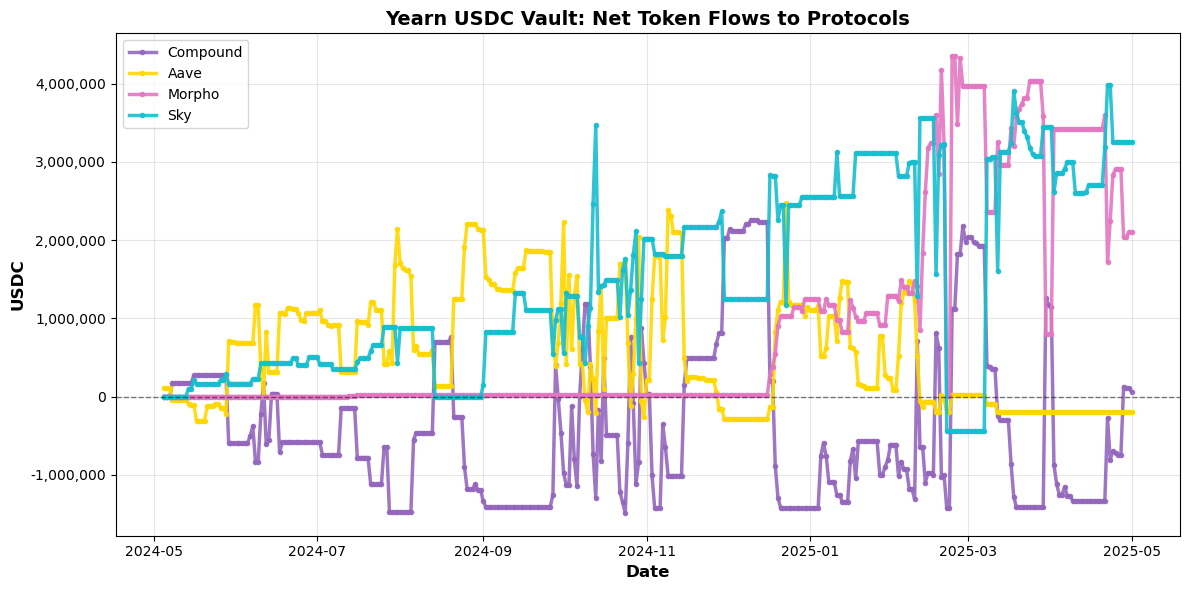

In [11]:
protocol_addresses = {
    # Compound
    "0xc3d688b66703497daa19211eedff47f25384cdc3": "Compound",
    # Aave
    "0x98c23e9d8f34fefb1b7bd6a91b7ff122f4e16f5c": "Aave",
    "0x2a1fbcb52ed4d9b23dad17e1e8aed4bb0e6079b8": "Aave",
    # Morpho
    "0xbbbbbbbbbb9cc5e90e3b3af64bdaf62c37eeffcb": "Morpho",
    # Sky
    "0x37305b1cd40574e4c5ce33f8e8306be057fd7341": "Sky",
    "0x0a59649758aa4d66e25f08dd01271e891fe52199": "Sky"
}

from yield_aggregators.yearn_analysis import plot_strategy_investment_protocol_flows

fig = plot_strategy_investment_protocol_flows(
    transactions_df=yearn_transactions,
    transfers_df=yearn_token_transfers,
    function_signatures=function_signatures,
    vault_address=yearn_USDC_vault_address,
    protocol_addresses=protocol_addresses,
    time_column='datetime',
    freq='D',
    title='Yearn USDC Vault: Net Token Flows to Protocols',
    figsize=(12, 6),
    token_symbol='USDC',
    start_date='2024-05-01',
    end_date='2025-05-01'
)

In [12]:
from yield_aggregators.yearn_analysis import export_protocol_flows_to_csv

export_protocol_flows_to_csv(
    transactions_df=yearn_transactions,
    transfers_df=yearn_token_transfers,
    function_signatures=function_signatures,
    vault_address=yearn_USDC_vault_address,
    protocol_addresses=protocol_addresses,
    output_path='../results/raw_data/yearn_protocol_flows.csv',
    time_column='datetime',
    freq='D'
)

Protocol flows data exported to: ../results/raw_data/yearn_protocol_flows.csv


## Token Transfer Network

Graph of USDC transfers during `update_debt` (strategy rebalancing) operations. The vault is the root node; edges show token flows through intermediaries to DeFi protocols.

\nNetwork contains 20 nodes and 22 edges


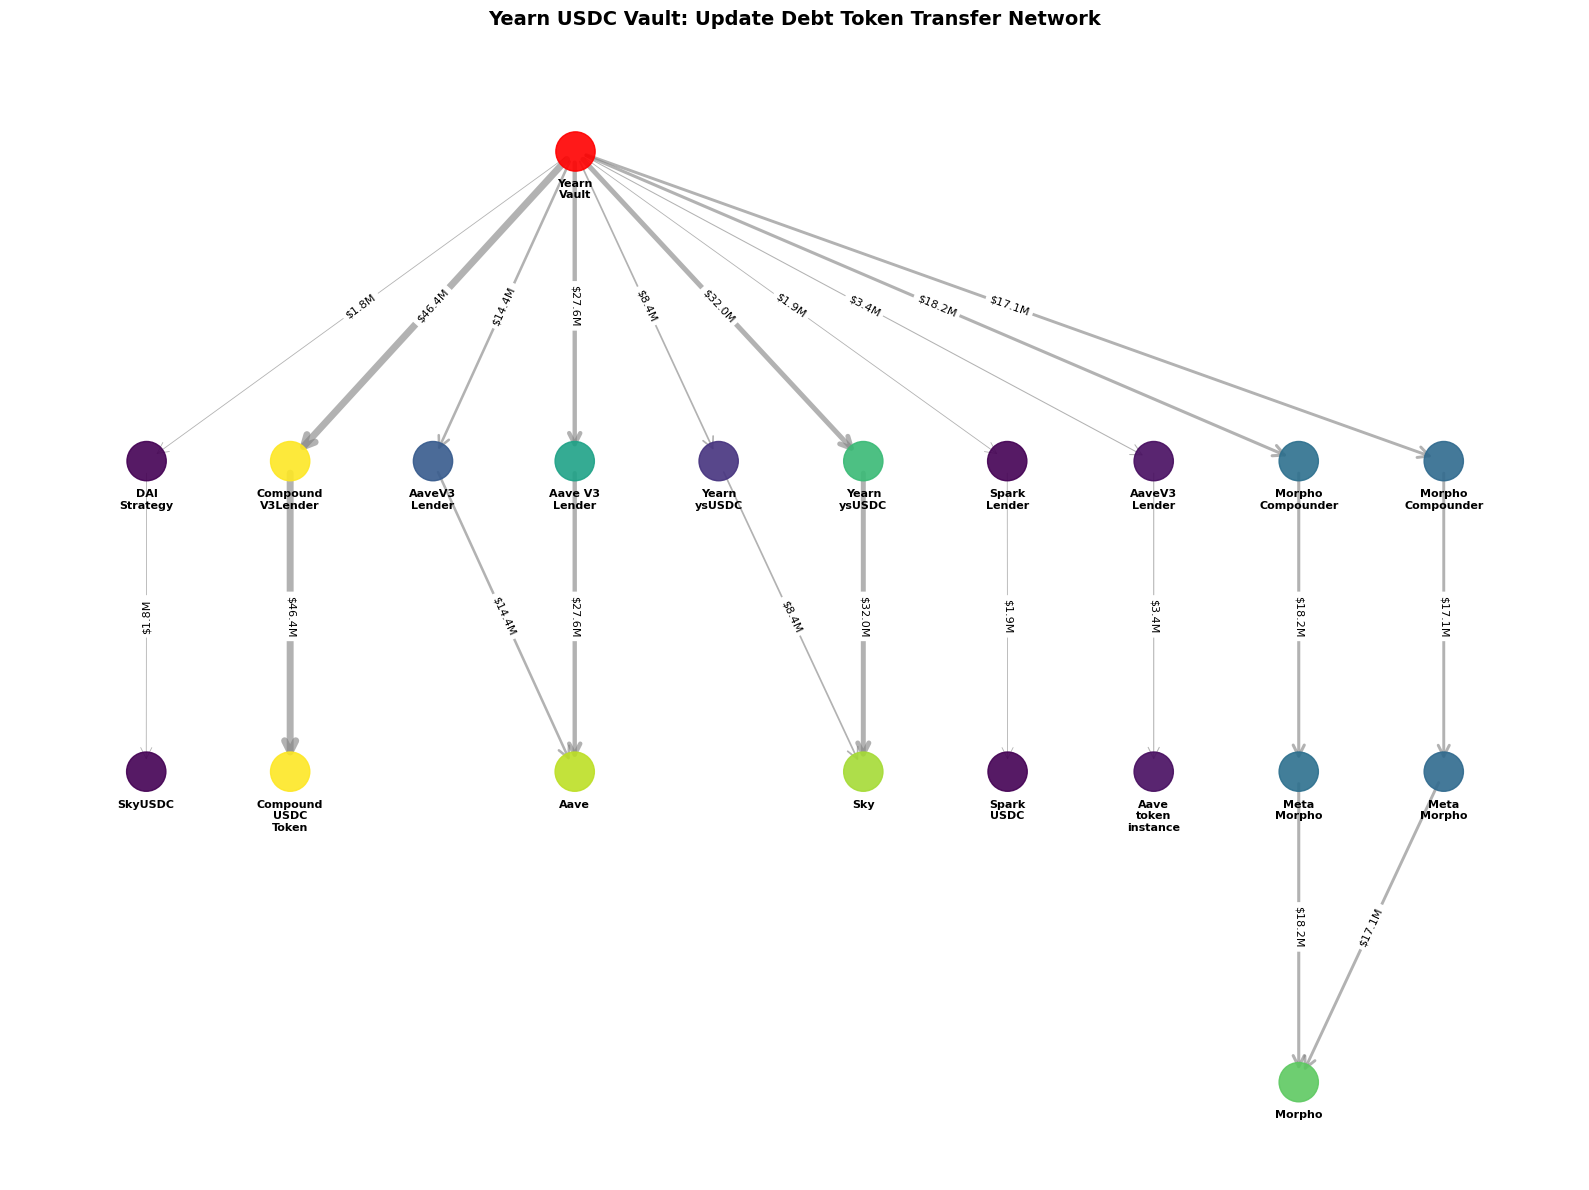

In [13]:
from yield_aggregators.yearn_network_visualization import (
    create_update_debt_network,
    visualize_update_debt_network
)

update_debt_network = create_update_debt_network(
    transactions_df=yearn_transactions,
    transfers_df=yearn_token_transfers,
    vault_address=yearn_USDC_vault_address,
    function_signatures=function_signatures
)

fig = visualize_update_debt_network(
    G=update_debt_network,
    vault_address=yearn_USDC_vault_address,
    title='Yearn USDC Vault: Update Debt Token Transfer Network',
    figsize=(16, 12)
)

print(f"\\nNetwork contains {len(update_debt_network.nodes())} nodes and {len(update_debt_network.edges())} edges")

In [14]:
from yield_aggregators.yearn_network_visualization import export_network_data

export_network_data(
    G=update_debt_network,
    output_path='../results/raw_data/yearn_update_debt_network'
)

Nodes exported to: ../results/raw_data/yearn_update_debt_network_nodes.csv
Edges exported to: ../results/raw_data/yearn_update_debt_network_edges.csv

Network Summary:
  Nodes: 20
  Edges: 22
  Total token flow: $377,461,759.37


## Vault Exchange Rate

USDC assets per share over time. An increasing rate indicates positive yield generated for shareholders.


VAULT EXCHANGE RATE ANALYSIS
Starting rate: 1.005676 USDC per share
Ending rate:   1.059890 USDC per share
Total change:  +5.39%


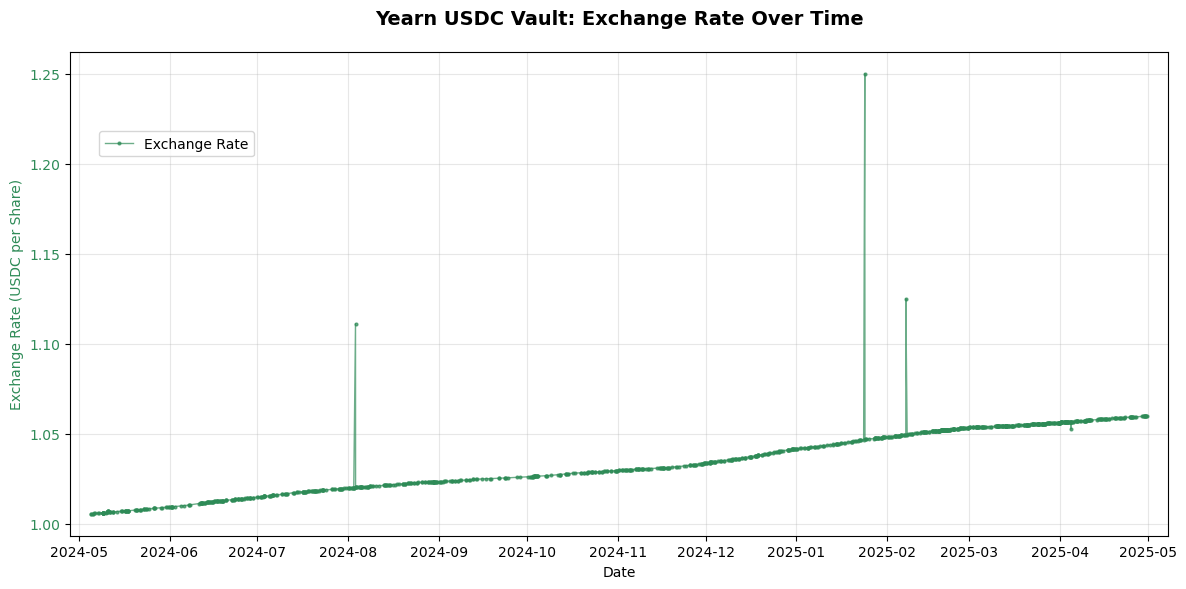

In [15]:
yearn_deposits = pd.read_csv('../data/yearn_vault_events/yearn_deposit_logs.csv')
yearn_withdraws = pd.read_csv('../data/yearn_vault_events/yearn_withdraw_logs.csv')
yearn_vault_events = pd.concat([yearn_deposits, yearn_withdraws], ignore_index=True)

fig = plot_vault_exchange_rate_over_time(
    vault_events_df=yearn_vault_events,
    time_column='datetime',
    title='Yearn USDC Vault: Exchange Rate Over Time',
    figsize=(12, 6),
    token_symbol='USDC',
    start_date='2024-05-01',
    end_date='2025-05-01'
)

In [16]:
export_exchange_rate_to_csv(
    vault_events_df=yearn_vault_events,
    output_path='../results/raw_data/yearn_exchange_rate.csv',
    time_column='datetime',
    token_symbol='USDC'
)

Exchange rate data exported to: ../results/raw_data/yearn_exchange_rate.csv
